In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [16]:
# Define number of points per axis
n = 28
lin = np.linspace(-1, 1, n)

# Create grid
x, y, z = np.meshgrid(lin, lin, lin)
points = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T

# cut out speeds that are not needed
max_speed = 80
min_speed = 5    # necessary?
distances = np.linalg.norm(points, axis=1)
# cut out ball
points = points[(distances <= 1) & (distances >= (min_speed / max_speed))]
points = points * 80

print(f"n: {n}, resulting rotations: {points.shape[0]}")

n: 28, resulting rotations: 10144


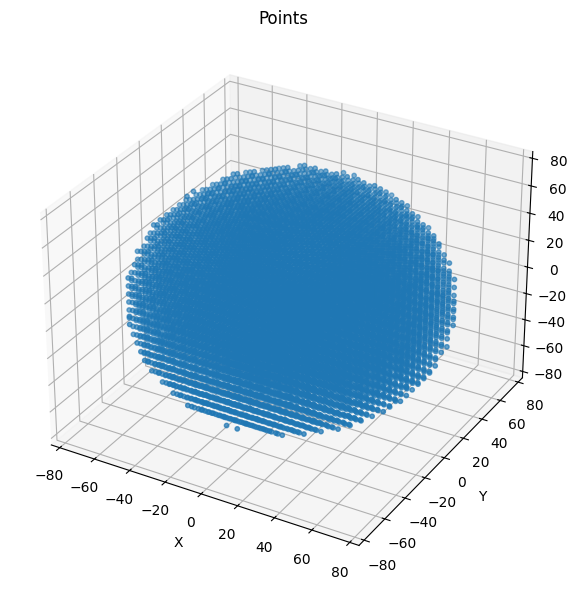

In [17]:
# Plotting
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=10)
ax.set_title("Points")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
plt.show()

In [20]:
import pyvista as pv
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [21]:
# Assume `points` is your (N, 3) numpy array
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Visualize
o3d.visualization.draw_geometries([pcd])